# Level Detection Workbench

This notebook is a staged workbench for the hierarchy workflow.

It is meant to answer three questions in order:

1. Do the reviewed outputs look sane?
2. Does the reviewed network pass the directed-graph checks?
3. What bifurcation-confluence units and summary metrics do we get if the graph is valid?

The notebook is intentionally a validation notebook first and a metrics notebook second.

In [8]:
from pathlib import Path
import json
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

candidate_roots = [Path.cwd().resolve()]
candidate_roots.extend(candidate_roots[0].parents)
REPO_ROOT = next(path for path in candidate_roots if (path / "hierarchy_level_definition").exists())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from hierarchy_level_definition.graph_building.directed_network_checks import analyze_reviewed_network
from hierarchy_level_definition.unit_detection.bifurcation_confluence_units import analyze_network
from hierarchy_level_definition.metrics.unit_metrics import compute_unit_metrics_from_units

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

REPO_ROOT

PosixPath('/Users/6256481/Code/river-hierarchy')

## 1. Review Output Inspection

Pick a reviewed example and inspect the saved link/node files before building the graph.

In [9]:
network_name = "sarl_07"

review_dir = REPO_ROOT / "hierarchy_level_definition" / "manual_review" / "outputs" / network_name
links_path = review_dir / "directed_links.gpkg"
nodes_path = review_dir / "reviewed_nodes.gpkg"

pd.Series(
    {
        "network_name": network_name,
        "review_dir": str(review_dir),
        "links_path_exists": links_path.exists(),
        "nodes_path_exists": nodes_path.exists(),
        "links_path": str(links_path),
        "nodes_path": str(nodes_path),
    }
)

network_name                                                   sarl_07
review_dir           /Users/6256481/Code/river-hierarchy/hierarchy_...
links_path_exists                                                 True
nodes_path_exists                                                 True
links_path           /Users/6256481/Code/river-hierarchy/hierarchy_...
nodes_path           /Users/6256481/Code/river-hierarchy/hierarchy_...
dtype: object

In [10]:
if not links_path.exists() or not nodes_path.exists():
    raise FileNotFoundError("Reviewed links/nodes files are missing for the selected network.")

links = gpd.read_file(links_path)
nodes = gpd.read_file(nodes_path)

print(f"links: {len(links)} rows")
print(f"nodes: {len(nodes)} rows")
print("link columns:", list(links.columns))
print("node columns:", list(nodes.columns))

display(links.head())
display(nodes.head())

links: 25 rows
nodes: 18 rows
link columns: ['id_link', 'idx_link', 'id_nodes', 'n_nodes', 'id_us_node', 'id_ds_node', 'is_inlet', 'is_outlet', 'type_io', 'schema_rg', 'link_conn', 'wid_pix', 'len', 'wid', 'wid_adj', 'wid_med', 'len_adj', 'sinuosity', 'manual_direction_reviewed', 'manual_us_node', 'manual_ds_node', 'geometry_reversed_manual', 'geometry']
node columns: ['id_node', 'idx_node', 'id_links', 'n_links', 'is_inlet', 'is_outlet', 'type_io', 'schema_rg', 'source_is_inlet', 'source_is_outlet', 'manual_role', 'node_role_reviewed', 'geometry']


,id_link,idx_link,id_nodes,n_nodes,id_us_node,id_ds_node,is_inlet,is_outlet,type_io,schema_rg,link_conn,wid_pix,len,wid,wid_adj,wid_med,len_adj,sinuosity,manual_direction_reviewed,manual_us_node,manual_ds_node,geometry_reversed_manual,geometry
0,0,"8, 371, 734, 1097, 1460, 1823, 2186, 2549, 291...","1, 0",2,1,0,False,True,inlet,rg-v1,"1, 2","596.3553913061276, 599.329750861146, 608.16555...",4464.038502,1075.194665,1128.139238,1094.762973,3704.124254,1.097237,True,1,0,True,"LINESTRING (228078.371 9357847.932, 228048.553..."
1,1,"45799, 46161, 46524, 46887, 47250, 47613, 4797...","2, 1",2,2,1,False,False,neither,rg-v1,"0, 2, 3","837.0246787864576, 902.4494632799865, 912.2483...",1988.800050,700.891496,628.955235,596.355391,1084.912876,1.082382,True,2,1,True,"LINESTRING (228883.451 9356357.043, 228853.633..."
2,2,"45799, 46163, 46164, 46528, 46892, 47256, 4762...","2, 1",2,2,1,False,False,neither,rg-v1,"0, 1, 3","837.0246787864576, 784.3830519841694, 725.4976...",2126.779304,347.327874,189.738008,183.745375,1188.836193,1.095315,True,2,1,True,"LINESTRING (228883.451 9356357.043, 228913.269..."
3,3,"63976, 64340, 64704, 65068, 65431, 65795, 6615...","3, 2",2,3,2,False,False,neither,rg-v1,"1, 2, 4, 5","834.8975478285786, 894.5330869591913, 954.1686...",1921.051754,893.849359,907.999098,908.341470,1057.214190,1.065168,True,3,2,True,"LINESTRING (229777.984 9354806.519, 229777.984..."
4,4,"82882, 83244, 83606, 83968, 84330, 84692, 8505...","4, 3",2,4,3,False,False,neither,rg-v1,"6, 3, 5","737.6508806285148, 666.7455968544942, 599.3297...",4225.496345,195.881869,90.171431,84.337388,3230.036778,1.130728,True,4,3,True,"LINESTRING (230702.335 9351645.836, 230672.517..."


,id_node,idx_node,id_links,n_links,is_inlet,is_outlet,type_io,schema_rg,source_is_inlet,source_is_outlet,manual_role,node_role_reviewed,geometry
0,1,45799,"1, 2, 0",3,False,False,neither,rg-v1,False,False,internal,True,POINT (228078.371 9357847.932)
1,0,8,0,1,False,True,inlet,rg-v1,True,False,outlet,True,POINT (226498.029 9361604.971)
2,2,63976,"1, 3, 2",3,False,False,neither,rg-v1,False,False,internal,True,POINT (228883.451 9356357.043)
3,3,82882,"3, 4, 5",3,False,False,neither,rg-v1,False,False,internal,True,POINT (229777.984 9354806.519)
4,4,121391,"4, 6, 5",3,False,False,neither,rg-v1,False,False,internal,True,POINT (230702.335 9351645.836)


In [11]:
review_summary = pd.Series(
    {
        "n_links": len(links),
        "n_nodes": len(nodes),
        "n_flagged_inlets": int(nodes["is_inlet"].fillna(False).astype(bool).sum()) if "is_inlet" in nodes.columns else None,
        "n_flagged_outlets": int(nodes["is_outlet"].fillna(False).astype(bool).sum()) if "is_outlet" in nodes.columns else None,
        "n_reversed_geometries": int(links["geometry_reversed_manual"].fillna(False).astype(bool).sum()) if "geometry_reversed_manual" in links.columns else None,
        "manual_role_counts": nodes["manual_role"].value_counts(dropna=False).to_dict() if "manual_role" in nodes.columns else None,
    }
)

review_summary

n_links                                                         25
n_nodes                                                         18
n_flagged_inlets                                                 1
n_flagged_outlets                                                1
n_reversed_geometries                                           18
manual_role_counts       {'internal': 16, 'outlet': 1, 'inlet': 1}
dtype: object

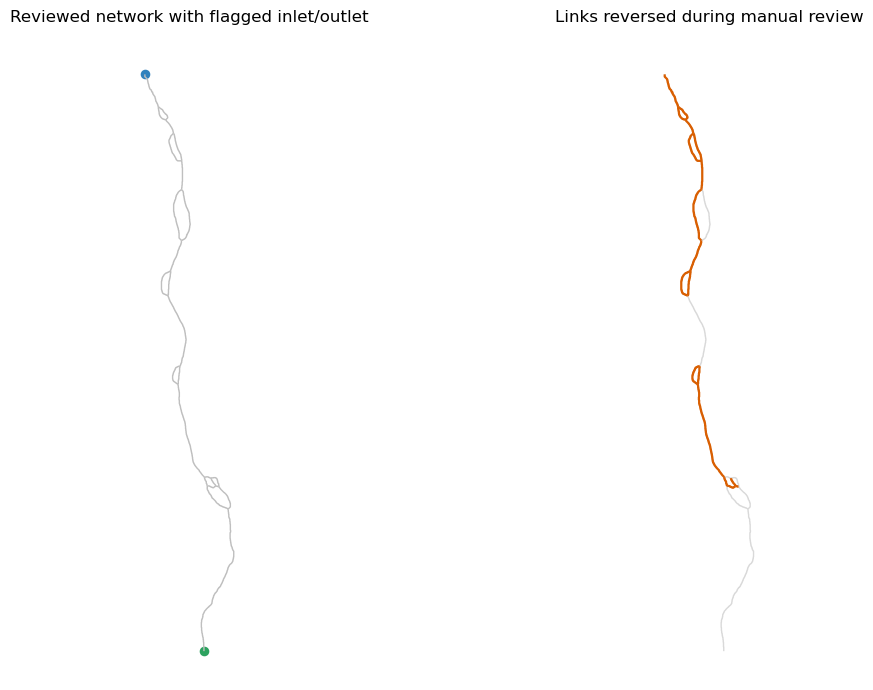

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

links.plot(ax=axes[0], color="0.75", linewidth=1)
if "is_inlet" in nodes.columns:
    nodes.loc[nodes["is_inlet"].fillna(False).astype(bool)].plot(ax=axes[0], color="#2ca25f", markersize=35)
if "is_outlet" in nodes.columns:
    nodes.loc[nodes["is_outlet"].fillna(False).astype(bool)].plot(ax=axes[0], color="#3182bd", markersize=35)
axes[0].set_title("Reviewed network with flagged inlet/outlet")
axes[0].set_axis_off()

links.plot(ax=axes[1], color="0.85", linewidth=1)
if "geometry_reversed_manual" in links.columns:
    reversed_links = links.loc[links["geometry_reversed_manual"].fillna(False).astype(bool)]
    if not reversed_links.empty:
        reversed_links.plot(ax=axes[1], color="#d95f02", linewidth=1.6)
axes[1].set_title("Links reversed during manual review")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

## 2. Graph Validation Diagnostics

Build the directed graph from the reviewed files and treat this as a validation gate.

We want exactly one source/inlet, exactly one sink/outlet, no isolated nodes, and no extra local minima/maxima.

In [13]:
import networkx as nx 

In [14]:
# [n for n in graph.nodes() if graph.out_degree(n) > 1]

In [15]:
graph, degree_frame, report = analyze_reviewed_network(links_path, nodes_path)
report_dict = report.to_dict()

print(json.dumps(report_dict, indent=2))

{
  "is_valid": true,
  "n_nodes": 18,
  "n_edges": 25,
  "n_weak_components": 1,
  "weak_components": [
    [
      0,
      1,
      2,
      3,
      4,
      5,
      6,
      7,
      8,
      9,
      10,
      11,
      12,
      13,
      14,
      15,
      16,
      17
    ]
  ],
  "source_nodes": [
    17
  ],
  "sink_nodes": [
    0
  ],
  "isolated_nodes": [],
  "flagged_inlets": [
    17
  ],
  "flagged_outlets": [
    0
  ],
  "issues": []
}


In [16]:
issues = pd.DataFrame({"issue": report.issues}) if report.issues else pd.DataFrame({"issue": ["No issues. Graph passes the current validation checks."]})
sources = degree_frame.loc[degree_frame["is_source"]]
sinks = degree_frame.loc[degree_frame["is_sink"]]
isolated = degree_frame.loc[degree_frame["is_isolated"]]
flagged = degree_frame.loc[degree_frame["flag_is_inlet"] | degree_frame["flag_is_outlet"]]

display(issues)
display(sources)
display(sinks)
display(isolated)
display(flagged)

,issue
0,No issues. Graph passes the current validation...


,node_id,in_degree,out_degree,total_degree,n_unique_predecessors,n_unique_successors,simple_in_degree,simple_out_degree,is_source,is_sink,is_isolated,flag_is_inlet,flag_is_outlet
17,17,0,1,1,0,1,0,1,True,False,False,True,False


,node_id,in_degree,out_degree,total_degree,n_unique_predecessors,n_unique_successors,simple_in_degree,simple_out_degree,is_source,is_sink,is_isolated,flag_is_inlet,flag_is_outlet
0,0,1,0,1,1,0,1,0,False,True,False,False,True


,node_id,in_degree,out_degree,total_degree,n_unique_predecessors,n_unique_successors,simple_in_degree,simple_out_degree,is_source,is_sink,is_isolated,flag_is_inlet,flag_is_outlet


,node_id,in_degree,out_degree,total_degree,n_unique_predecessors,n_unique_successors,simple_in_degree,simple_out_degree,is_source,is_sink,is_isolated,flag_is_inlet,flag_is_outlet
0,0,1,0,1,1,0,1,0,False,True,False,False,True
17,17,0,1,1,0,1,0,1,True,False,False,True,False


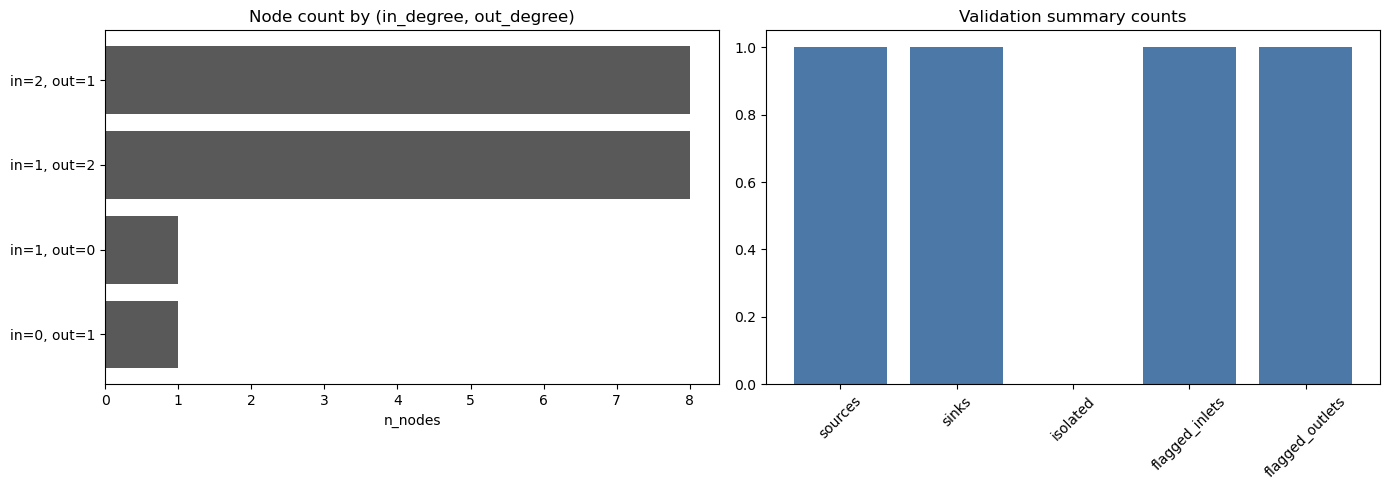

In [17]:
if not report.is_valid:
    raise ValueError("Graph validation failed. Fix the reviewed network before running unit detection.")

summary, units, hierarchy = analyze_network(links_path, nodes_path)
unit_metrics, path_metrics = compute_unit_metrics_from_units(links, units)

print(f"Detected {len(units)} unit(s).")
display(summary)
display(unit_metrics)


if path_metrics.empty:
    print("No path-level metrics detected for this network.")
else:
    display(path_metrics)
    metrics_table = pd.DataFrame(
        {
            "metric": [
                "n_units",
                "n_compound_units",
                "n_leaf_units",
                "max_depth_from_root",
                "max_collapse_level",
                "median_equivalent_length",
                "median_equivalent_width",
                "median_elongation",
            ],
            "value": [
                len(unit_metrics),
                int(unit_metrics["is_compound"].fillna(False).sum()),
                int((~unit_metrics["is_compound"].fillna(False)).sum()),
                unit_metrics["depth_from_root"].max(),
                unit_metrics["collapse_level"].max(),
                unit_metrics["equivalent_length"].median(),
                unit_metrics["equivalent_width"].median(),
                unit_metrics["elongation"].median(),
            ],
        }
    )
    display(metrics_table)


In [18]:
if unit_metrics.empty:
    print("No unit plots to show.")
else:
    class_counts = unit_metrics["class"].value_counts(dropna=False).rename_axis("class").reset_index(name="n_units")

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].bar(class_counts["class"], class_counts["n_units"], color="#59a14f")
    axes[0].set_title("Unit count by class")
    axes[0].tick_params(axis="x", rotation=35)

    axes[1].scatter(unit_metrics["equivalent_width"], unit_metrics["equivalent_length"], c=unit_metrics["n_paths"], cmap="viridis", s=50)
    axes[1].set_title("Equivalent width vs equivalent length")
    axes[1].set_xlabel("equivalent_width")
    axes[1].set_ylabel("equivalent_length")

    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(15, 5))
    ax.hlines(unit_metrics["unit_id"], unit_metrics["path_length_min"], unit_metrics["path_length_max"], color="0.45")
    ax.scatter(unit_metrics["path_length_min"], unit_metrics["unit_id"], color="#2ca25f", label="min")
    ax.scatter(unit_metrics["path_length_max"], unit_metrics["unit_id"], color="#3182bd", label="max")
    ax.set_title("Path-length range by unit")
    ax.set_xlabel("path length")
    ax.set_ylabel("unit_id")
    ax.legend()
    plt.tight_layout()
    plt.show()


Detected 8 unit(s).


,unit_id,bifurcation,confluence,n_paths,class,min_path_length,max_path_length,children,parents,path_cutoff_used,path_enumeration_truncated
0,1,2,1,2,simple_bifurcation_confluence_pair,1084.912876,1188.836193,,,1,False
1,2,4,3,2,simple_bifurcation_confluence_pair,2562.572676,3230.036778,,,1,False
2,3,6,5,2,simple_bifurcation_confluence_pair,5478.720420,5689.563891,,,1,False
3,4,8,7,2,simple_bifurcation_confluence_pair,1875.522646,2771.297063,,,1,False
4,5,10,9,2,simple_bifurcation_confluence_pair,1093.025633,1892.111738,,,1,False
5,6,14,11,2,compound_or_nested_complex,1248.471732,1271.054497,,,3,False
6,7,15,12,2,compound_or_nested_complex,900.890338,1400.557416,,,2,False
7,8,16,13,2,compound_or_nested_complex,3343.314183,3420.416567,,,3,False


In [19]:
if summary.empty:
    print("No units detected for this network.")
else:
    class_counts = summary["class"].value_counts(dropna=False).rename_axis("class").reset_index(name="n_units")
    metrics_table = pd.DataFrame(
        {
            "metric": [
                "n_units",
                "n_unique_bifurcations",
                "n_unique_confluences",
                "min_n_paths",
                "max_n_paths",
                "median_n_paths",
                "min_path_length_min",
                "max_path_length_max",
            ],
            "value": [
                len(summary),
                summary["bifurcation"].nunique(),
                summary["confluence"].nunique(),
                summary["n_paths"].min(),
                summary["n_paths"].max(),
                summary["n_paths"].median(),
                summary["min_path_length"].min(),
                summary["max_path_length"].max(),
            ],
        }
    )

    display(class_counts)
    display(metrics_table)

,class,n_units
0,simple_bifurcation_confluence_pair,5
1,compound_or_nested_complex,3


,metric,value
0,n_units,8.000000
1,n_unique_bifurcations,8.000000
2,n_unique_confluences,8.000000
3,min_n_paths,2.000000
4,max_n_paths,2.000000
5,median_n_paths,2.000000
6,min_path_length_min,900.890338
7,max_path_length_max,5689.563891


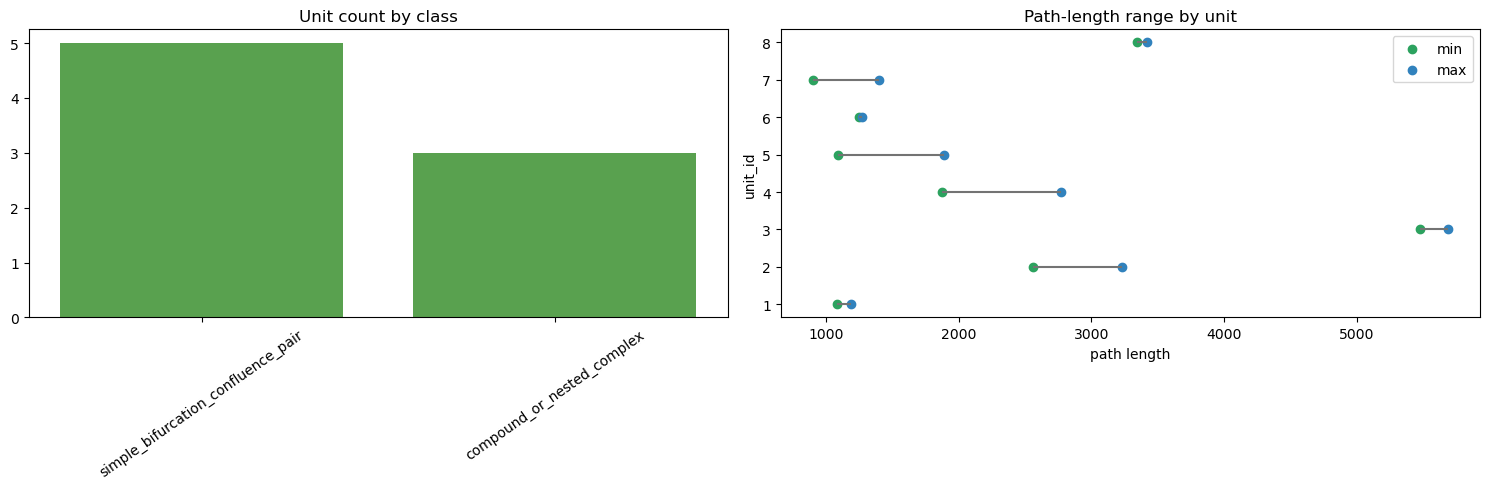

In [20]:
if summary.empty:
    print("No unit plots to show.")
else:
    class_counts = summary["class"].value_counts(dropna=False).rename_axis("class").reset_index(name="n_units")

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].bar(class_counts["class"], class_counts["n_units"], color="#59a14f")
    axes[0].set_title("Unit count by class")
    axes[0].tick_params(axis="x", rotation=35)

    axes[1].hlines(summary["unit_id"], summary["min_path_length"], summary["max_path_length"], color="0.45")
    axes[1].scatter(summary["min_path_length"], summary["unit_id"], color="#2ca25f", label="min")
    axes[1].scatter(summary["max_path_length"], summary["unit_id"], color="#3182bd", label="max")
    axes[1].set_title("Path-length range by unit")
    axes[1].set_xlabel("path length")
    axes[1].set_ylabel("unit_id")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [21]:
def hierarchy_lines(nodes, indent=0):
    lines = []
    for node in nodes:
        lines.append(
            "  " * indent
            + f"unit {node['unit_id']}: bif={node['bifurcation']}, conf={node['confluence']}, paths={node['n_paths']}, class={node['class']}"
        )
        lines.extend(hierarchy_lines(node["children"], indent + 1))
    return lines

if hierarchy:
    print("\n".join(hierarchy_lines(hierarchy)))
else:
    print("Hierarchy is empty.")

unit 1: bif=2, conf=1, paths=2, class=simple_bifurcation_confluence_pair
unit 2: bif=4, conf=3, paths=2, class=simple_bifurcation_confluence_pair
unit 3: bif=6, conf=5, paths=2, class=simple_bifurcation_confluence_pair
unit 4: bif=8, conf=7, paths=2, class=simple_bifurcation_confluence_pair
unit 5: bif=10, conf=9, paths=2, class=simple_bifurcation_confluence_pair
unit 6: bif=14, conf=11, paths=2, class=compound_or_nested_complex
unit 7: bif=15, conf=12, paths=2, class=compound_or_nested_complex
unit 8: bif=16, conf=13, paths=2, class=compound_or_nested_complex


In [ ]:
# tejedor 

In [22]:
from hierarchy_level_definition.metrics import compute_unit_metrics
summary, unit_metrics, path_metrics = compute_unit_metrics(links_path, nodes_path)


In [23]:
summary

,unit_id,bifurcation,confluence,n_paths,class,min_path_length,max_path_length,children,parents,path_cutoff_used,path_enumeration_truncated
0,1,2,1,2,simple_bifurcation_confluence_pair,1084.912876,1188.836193,,,1,False
1,2,4,3,2,simple_bifurcation_confluence_pair,2562.572676,3230.036778,,,1,False
2,3,6,5,2,simple_bifurcation_confluence_pair,5478.720420,5689.563891,,,1,False
3,4,8,7,2,simple_bifurcation_confluence_pair,1875.522646,2771.297063,,,1,False
4,5,10,9,2,simple_bifurcation_confluence_pair,1093.025633,1892.111738,,,1,False
5,6,14,11,2,compound_or_nested_complex,1248.471732,1271.054497,,,3,False
6,7,15,12,2,compound_or_nested_complex,900.890338,1400.557416,,,2,False
7,8,16,13,2,compound_or_nested_complex,3343.314183,3420.416567,,,3,False
